# 📘 UD4 – Fundamentos visuales de Deep Learning

Notebook de **comprensión visual** para entender las bases matemáticas del Deep Learning.

Todos los gráficos se **guardan como imágenes** para poder reutilizarlos en documentos y diapositivas.

## 1️⃣ Escalares, vectores y matrices

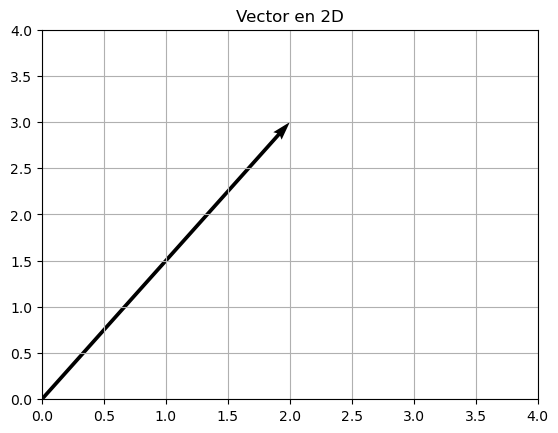

In [2]:
import numpy as np
import matplotlib.pyplot as plt

v = np.array([2, 3])

plt.figure()
plt.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1)
plt.xlim(0, 4)
plt.ylim(0, 4)
plt.title('Vector en 2D')
plt.grid(True)
plt.savefig('vector_2d.png')
plt.show()

Un **vector** puede verse como una flecha en el espacio.
En Deep Learning, datos y pesos se representan así.

## 2️⃣ Batches de datos

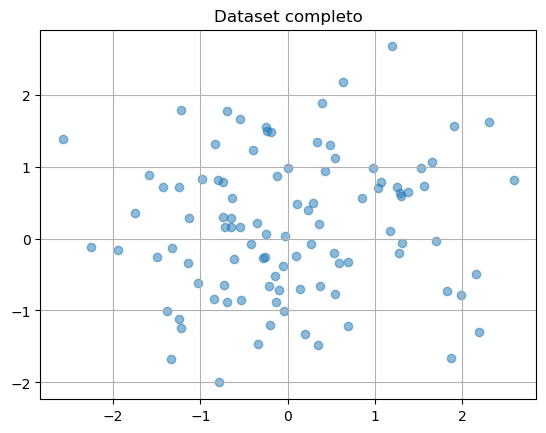

In [3]:
X = np.random.randn(100, 2)

plt.figure()
plt.scatter(X[:,0], X[:,1], alpha=0.5)
plt.title('Dataset completo')
plt.grid(True)
plt.savefig('dataset_completo.png')
plt.show()

El entrenamiento real usa **batches** para eficiencia y estabilidad.

## 3️⃣ Transformación lineal (capa neuronal)

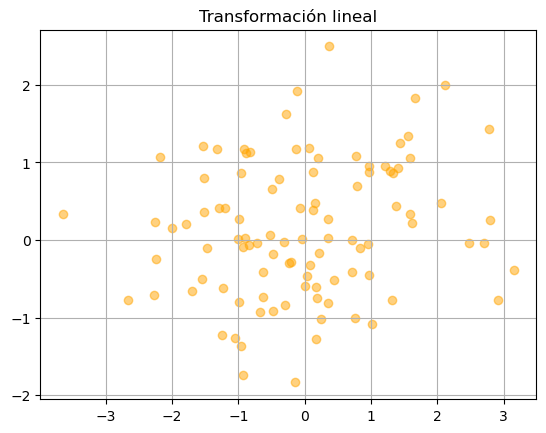

In [4]:
W = np.array([[1.2, 0.3], [-0.4, 0.8]])
X_trans = X @ W

plt.figure()
plt.scatter(X_trans[:,0], X_trans[:,1], alpha=0.5, color='orange')
plt.title('Transformación lineal')
plt.grid(True)
plt.savefig('transformacion_lineal.png')
plt.show()

Una capa neuronal **deforma el espacio de datos**.

## 4️⃣ Función de pérdida

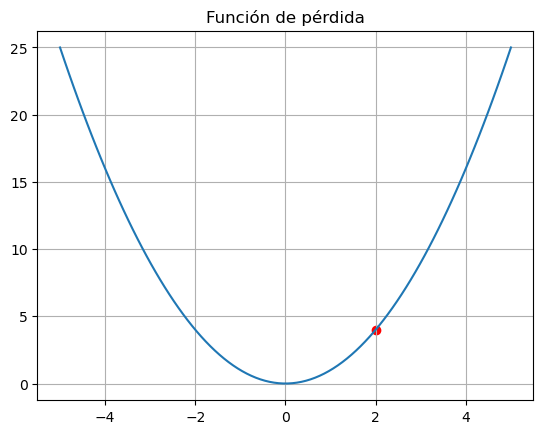

In [5]:
x = np.linspace(-5, 5, 100)
loss = x**2

plt.figure()
plt.plot(x, loss)
plt.scatter([2], [4], color='red')
plt.title('Función de pérdida')
plt.grid(True)
plt.savefig('funcion_perdida.png')
plt.show()

La pérdida mide **qué tan mal lo está haciendo el modelo**.

## 5️⃣ Gradiente descendente

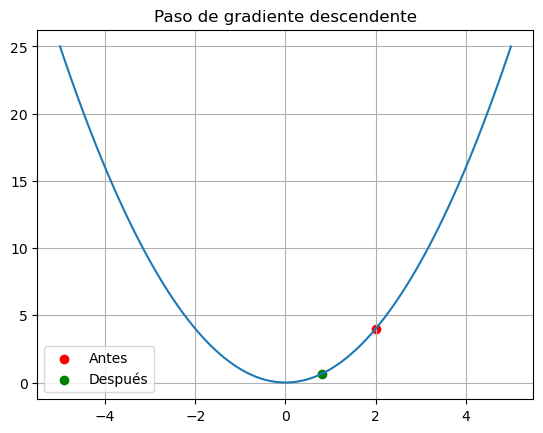

In [6]:
x0 = 2
grad = 2 * x0
x1 = x0 - 0.3 * grad

plt.figure()
plt.plot(x, loss)
plt.scatter([x0], [x0**2], color='red', label='Antes')
plt.scatter([x1], [x1**2], color='green', label='Después')
plt.legend()
plt.title('Paso de gradiente descendente')
plt.grid(True)
plt.savefig('gradiente_descendente.png')
plt.show()

El gradiente indica **cómo ajustar los pesos para reducir el error**.

## 6️⃣ Backpropagation (idea conceptual)

Backpropagation consiste en propagar el error hacia atrás y ajustar los pesos capa a capa.

📌 **Imágenes generadas y guardadas**:

- vector_2d.png
- dataset_completo.png
- transformacion_lineal.png
- funcion_perdida.png
- gradiente_descendente.png

Estas imágenes pueden insertarse directamente en documentos Markdown.

### Creación de imágenes didácticas para UD4

* ✅ **Capítulo 1**

  * Imágenes introductorias (ML vs DL, pipeline, inspiración biológica)
  * Poco peso visual, solo contextual

* 🔴 **Capítulo 2 (CLAVE)**

  * Escalares, vectores, matrices, tensores
  * Batches
  * Broadcasting
  * Producto matricial
  * Interpretación geométrica
  * Superficie de pérdida (entrada al gradiente)




## 🧪 SCRIPT PYTHON — Superficie de pérdida + Gradiente descendente

Este script:

* Define una **función de pérdida no trivial**
* Tiene **varios mínimos locales**
* Aplica **gradiente descendente**
* Dibuja:

  * la superficie
  * el recorrido del algoritmo paso a paso

### 📌 Qué puedes hacer con esto

* Ejecutarlo en notebook o script
* Guardar las figuras
* Usarlas luego en el documento teórico
* Animarlo si quieres (paso siguiente)

---



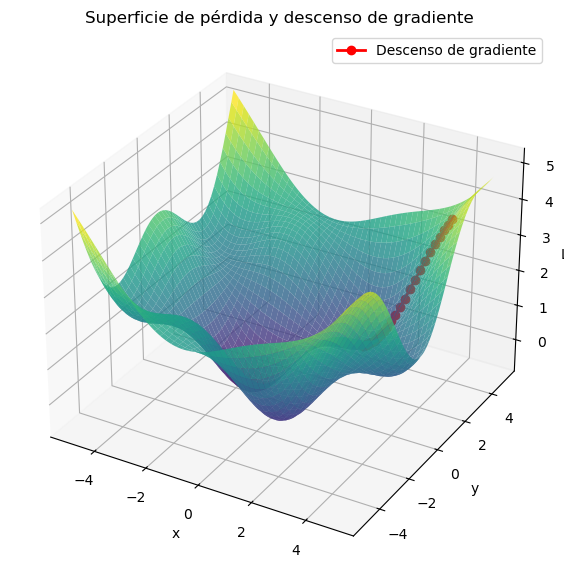

In [7]:
### 🧩 Script completo (NumPy + Matplotlib)
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


# ---------------------------
# 1. Función de pérdida
# ---------------------------
def loss_function(x, y):
    """
    Superficie con varios mínimos locales
    """
    return np.sin(x) * np.cos(y) + 0.1 * (x**2 + y**2)


# Gradiente analítico
def grad_loss(x, y):
    dx = np.cos(x) * np.cos(y) + 0.2 * x
    dy = -np.sin(x) * np.sin(y) + 0.2 * y
    return dx, dy


# ---------------------------
# 2. Crear superficie
# ---------------------------
x_vals = np.linspace(-5, 5, 200)
y_vals = np.linspace(-5, 5, 200)
X, Y = np.meshgrid(x_vals, y_vals)
Z = loss_function(X, Y)

# ---------------------------
# 3. Gradiente descendente
# ---------------------------
lr = 0.1
steps = 30

x, y = 4.0, 4.0  # punto inicial
trajectory = []

for _ in range(steps):
    trajectory.append((x, y, loss_function(x, y)))
    dx, dy = grad_loss(x, y)
    x -= lr * dx
    y -= lr * dy

trajectory = np.array(trajectory)

# ---------------------------
# 4. Visualización 3D
# ---------------------------
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(X, Y, Z, cmap="viridis", alpha=0.8)
ax.plot(
    trajectory[:, 0],
    trajectory[:, 1],
    trajectory[:, 2],
    color="red",
    marker="o",
    linewidth=2,
    label="Descenso de gradiente",
)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("Loss")
ax.set_title("Superficie de pérdida y descenso de gradiente")

ax.legend()
plt.show()


## 🧠 Explicación

Frases clave :

* *“Entrenar un modelo es moverse por esta superficie”*
* *“El gradiente indica la pendiente más pronunciada”*
* *“La tasa de aprendizaje decide cuánto avanzamos”*
* *“No siempre llegamos al mínimo global”*

# 🧪 1️⃣ ANIMACIÓN 3D — Descenso de gradiente

Esta versión es **impactante visualmente** y sirve para:

* reforzar la intuición
* conectar con la “superficie de pérdida”
* preparar el terreno para hablar de *learning rate*